In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

task1

In [21]:
df=pd.read_csv("data.csv",encoding="cp1252")
df.head()
df["Order Date"]=pd.to_datetime(df["Order Date"])
monthly = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum().reset_index()
)
monthly["Order Date"] = monthly["Order Date"].dt.to_timestamp()


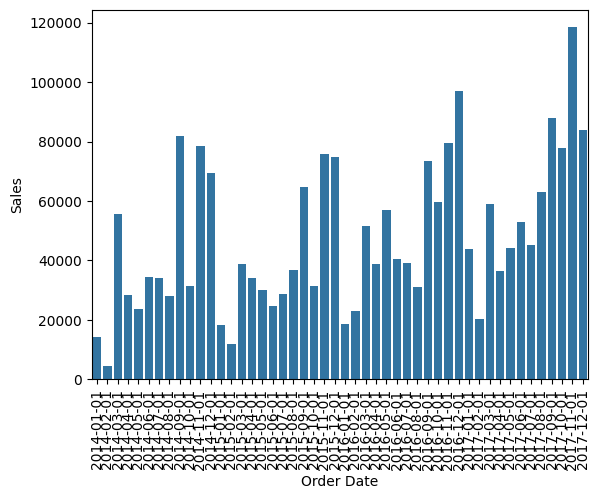

In [42]:

sns.barplot(monthly,x="Order Date", y="Sales")
plt.xticks(rotation=90)
plt.show()

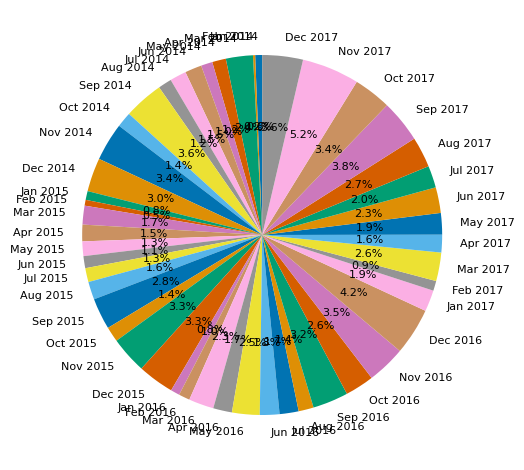

In [37]:
colors = sns.color_palette("colorblind")
plt.pie( monthly_sales["Sales"],labels=monthly_sales["Order Date"].dt.strftime("%b %Y"),colors=colors,autopct="%1.1f%%", startangle=90,
    textprops={"fontsize": 8})
plt.tight_layout()
plt.show()

<Axes: xlabel='Order Date', ylabel='Sales'>

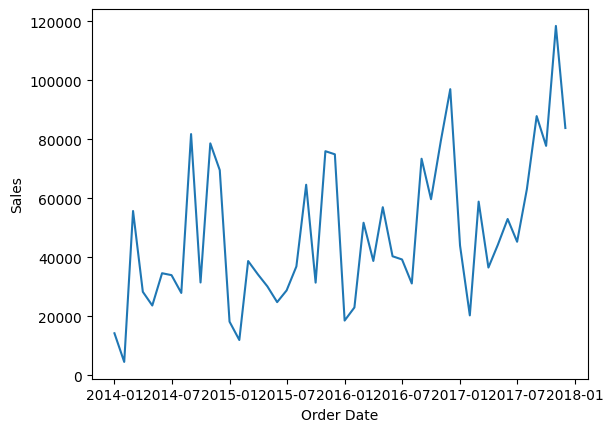

In [38]:
sns.lineplot(monthly,x="Order Date",y="Sales")

The best chart for showing this trend is bar in my opinion, it shows a year wise trend, doesnt make it too messy and is easy to read

task 2. 1

<Axes: xlabel='Sub-Category', ylabel='Sales'>

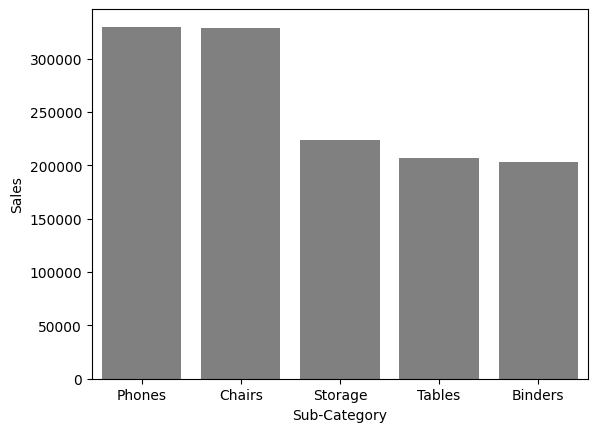

In [47]:
top = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)
sns.barplot(top, x="Sub-Category",y="Sales", color="grey" )


bar chart is good for showing an order of top categories, iit shows the sales and its easier to differentiate between categories instead of percentages like pie chart

2.2

<Axes: xlabel='Order Date', ylabel='Sales'>

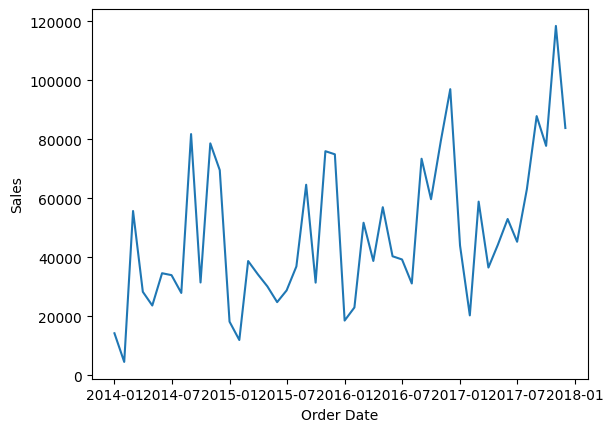

In [48]:
sns.lineplot(monthly,x="Order Date",y="Sales")

line chart is good for showing trend over a long period of time when it comes to revenue or profit. its a more general way of showing profit or loss

2.3

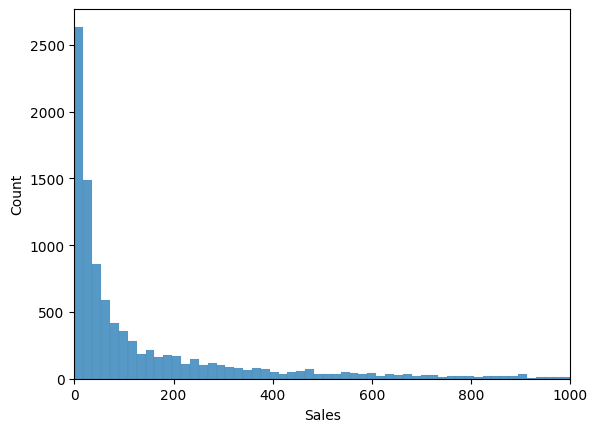

In [54]:
sns.histplot(df, x="Sales")
plt.xlim(0,1000)
plt.show()

histogram is good for showing distributions because it shows frequency

2.4

<Axes: xlabel='Discount', ylabel='Profit'>

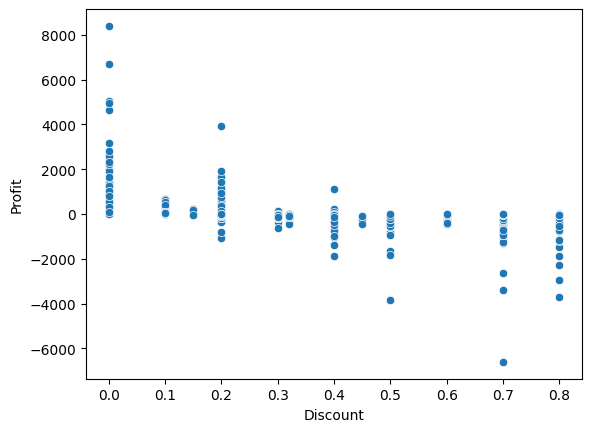

In [57]:
sns.scatterplot(df, x="Discount", y="Profit")

scatter is perfect for showing relationship as it shows where there os more condensation and clustering

task 3

/tmp/ipykernel_1127/28286741.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(region_sales, x="Region", y="Sales",palette="tab10")


<Axes: xlabel='Region', ylabel='Sales'>

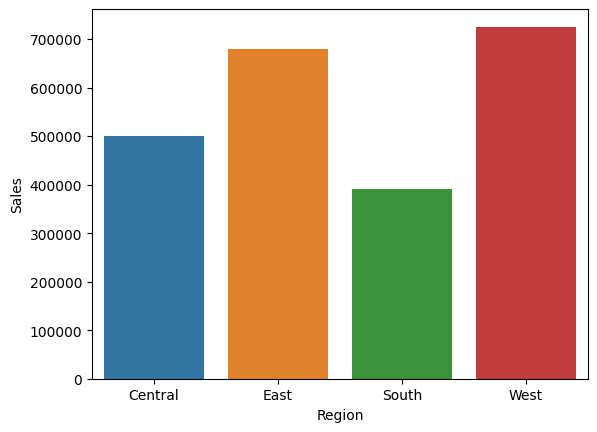

In [65]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .reset_index()
)
sns.barplot(region_sales, x="Region", y="Sales",palette="tab10")

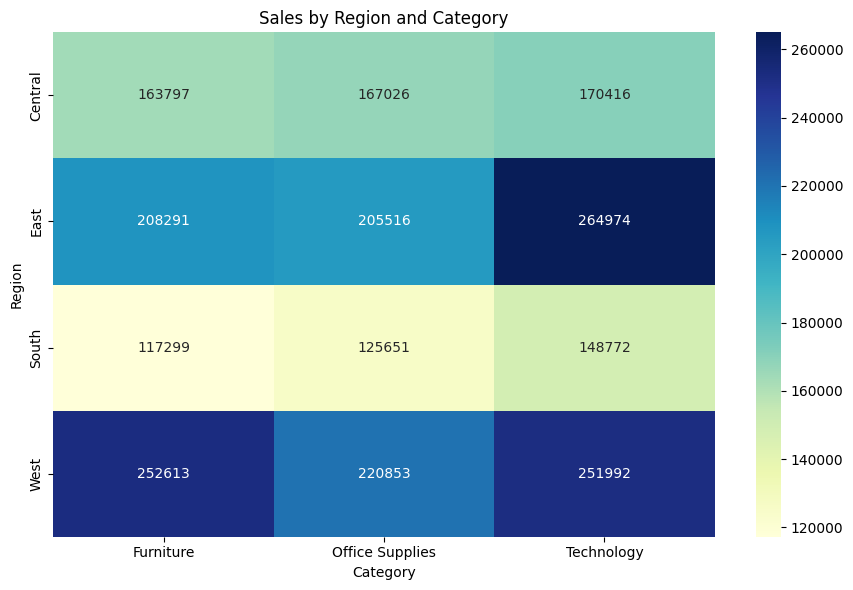

In [70]:
region_category_sales = df.pivot_table(
    index="Region",
    columns="Category",
    values="Sales",
    aggfunc="sum"
)

region_category_sales
plt.figure(figsize=(9, 6))

sns.heatmap(
    region_category_sales,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Sales by Region and Category")
plt.xlabel("Category")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

/tmp/ipykernel_1127/528001334.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(monthly_profit, x="Order Date", y="Profit", palette="RdBu")


<Axes: xlabel='Order Date', ylabel='Profit'>

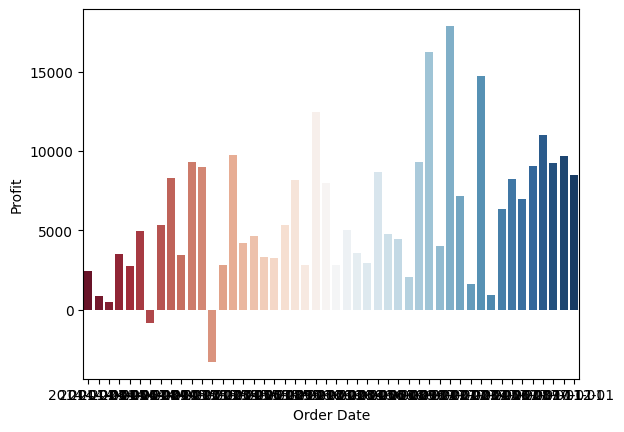

In [73]:
monthly_profit = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Profit"]
    .sum()
    .reset_index()
)

monthly_profit["Order Date"] = monthly_profit["Order Date"].dt.to_timestamp()
sns.barplot(monthly_profit, x="Order Date", y="Profit", palette="RdBu")

task4

In [82]:
def wcag(rgb):


    rgb = np.array(rgb) / 255.0

    values = np.where(
        rgb <= 0.03928,
        rgb / 12.92,
        ((rgb + 0.055) / 1.055) ** 2.4
    )

    return (
        0.2126 * values[0]
        + 0.7152 * values[1]
        + 0.0722 * values[2]
    )


def contrast_ratio(color1, color2):

    L1 = wcag(color1)
    L2 = wcag(color2)

    lighter = max(L1, L2)
    darker = min(L1, L2)

    return (lighter + 0.05) / (darker + 0.05)
test_colors = {
    "Blue": (31, 119, 180),
    "Orange": (255, 127, 14),
    "Green": (44, 160, 44),
    "White": (255, 255, 255),
    "Black": (0, 0, 0)
}

for name, rgb in test_colors.items():
    ratio = contrast_ratio(rgb, test_colors["White"])

    print(f"{name} vs White: {ratio:.2f}:1")

    if ratio >= 4.5:
        print("PASS - Meets WCAG AA")
    else:
        print("FAIL - Does not meet WCAG AA")

    print()

Blue vs White: 4.82:1
PASS - Meets WCAG AA

Orange vs White: 2.53:1
FAIL - Does not meet WCAG AA

Green vs White: 3.40:1
FAIL - Does not meet WCAG AA

White vs White: 1.00:1
FAIL - Does not meet WCAG AA

Black vs White: 21.00:1
PASS - Meets WCAG AA



<BarContainer object of 17 artists>

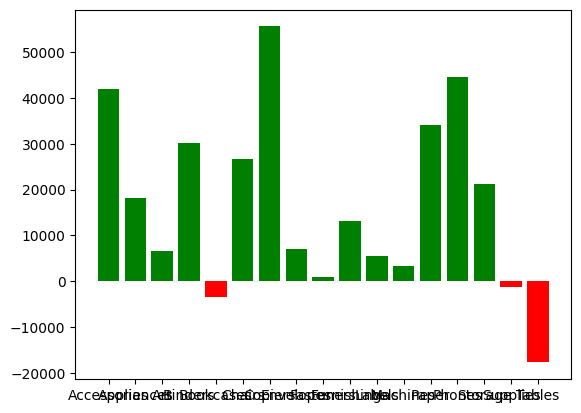

In [84]:
subcategory_profit = (
    df.groupby("Sub-Category")["Profit"]
    .sum()
    .reset_index()
)
colors = [
    "green" if profit >= 0 else "red"
    for profit in subcategory_profit["Profit"]
]
plt.bar(
    subcategory_profit["Sub-Category"],
    subcategory_profit["Profit"],
    color=colors
)


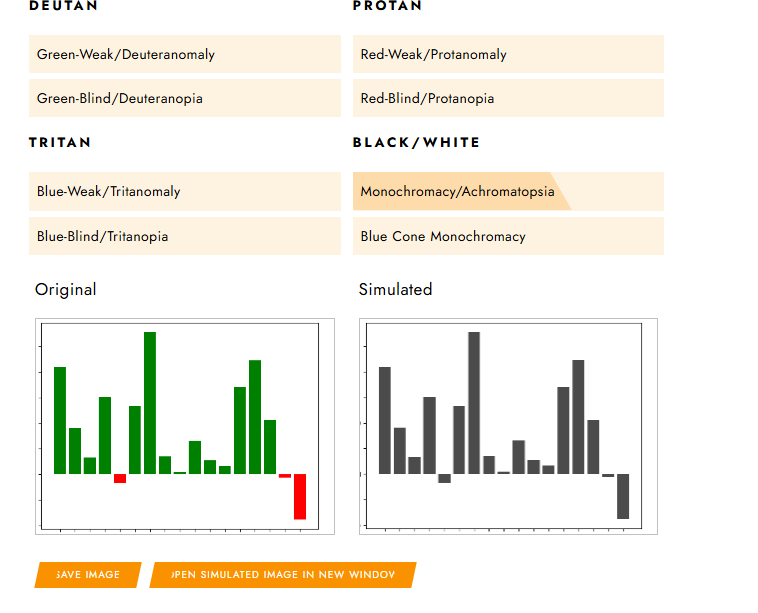

as we can see red and green are not good for colorblindness because they have a small wcag ratio too

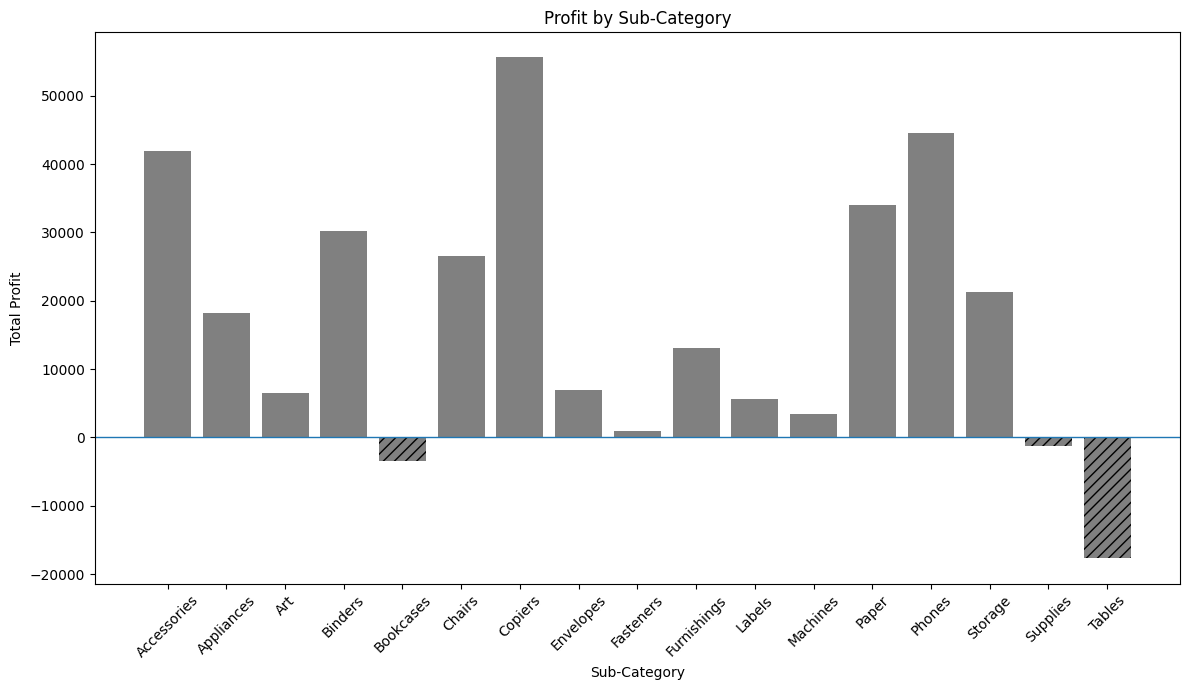

In [85]:
plt.figure(figsize=(12, 7))

for i, row in subcategory_profit.iterrows():

    if row["Profit"] >= 0:
        hatch = ""
    else:
        hatch = "///"

    plt.bar(
        row["Sub-Category"],
        row["Profit"],
        color="gray",
        hatch=hatch
    )

plt.axhline(0, linewidth=1)

plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

task5

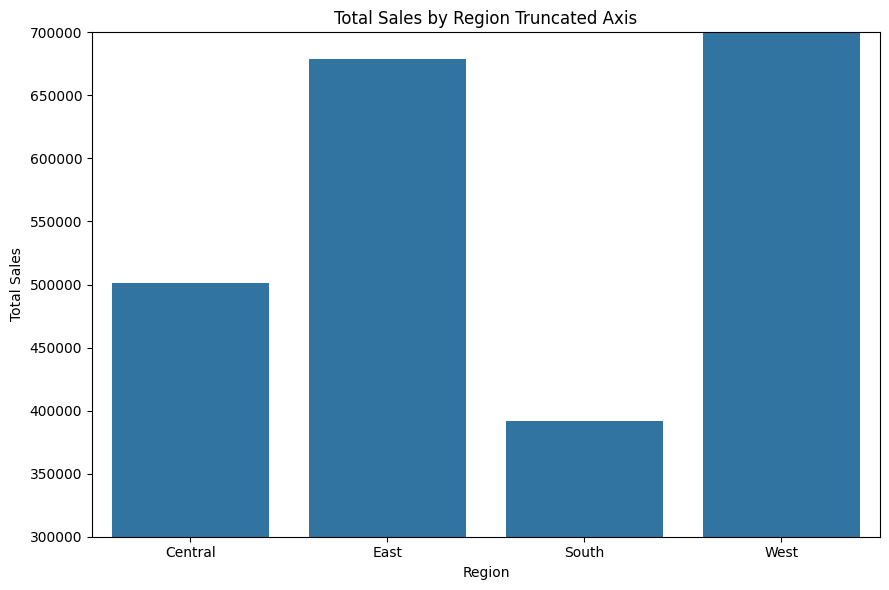

In [86]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=region_sales,
    x="Region",
    y="Sales"
)

plt.ylim(300000, 700000)

plt.title("Total Sales by Region Truncated Axis")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

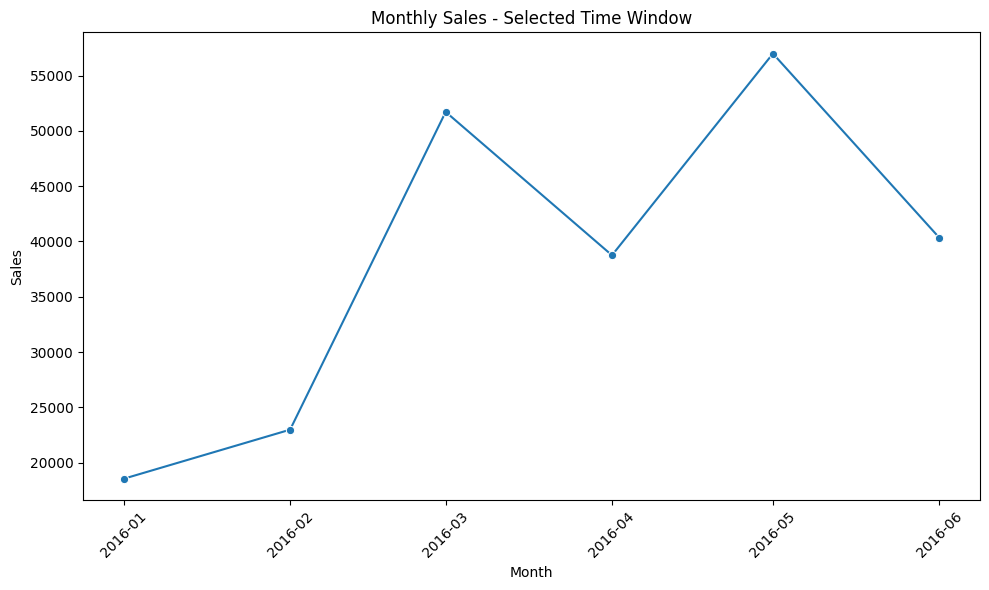

In [87]:
cherry_picked = monthly_sales[
    (monthly_sales["Order Date"] >= "2016-01-01") &
    (monthly_sales["Order Date"] <= "2016-06-01")
]

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=cherry_picked,
    x="Order Date",
    y="Sales",
    marker="o"
)

plt.title("Monthly Sales - Selected Time Window")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

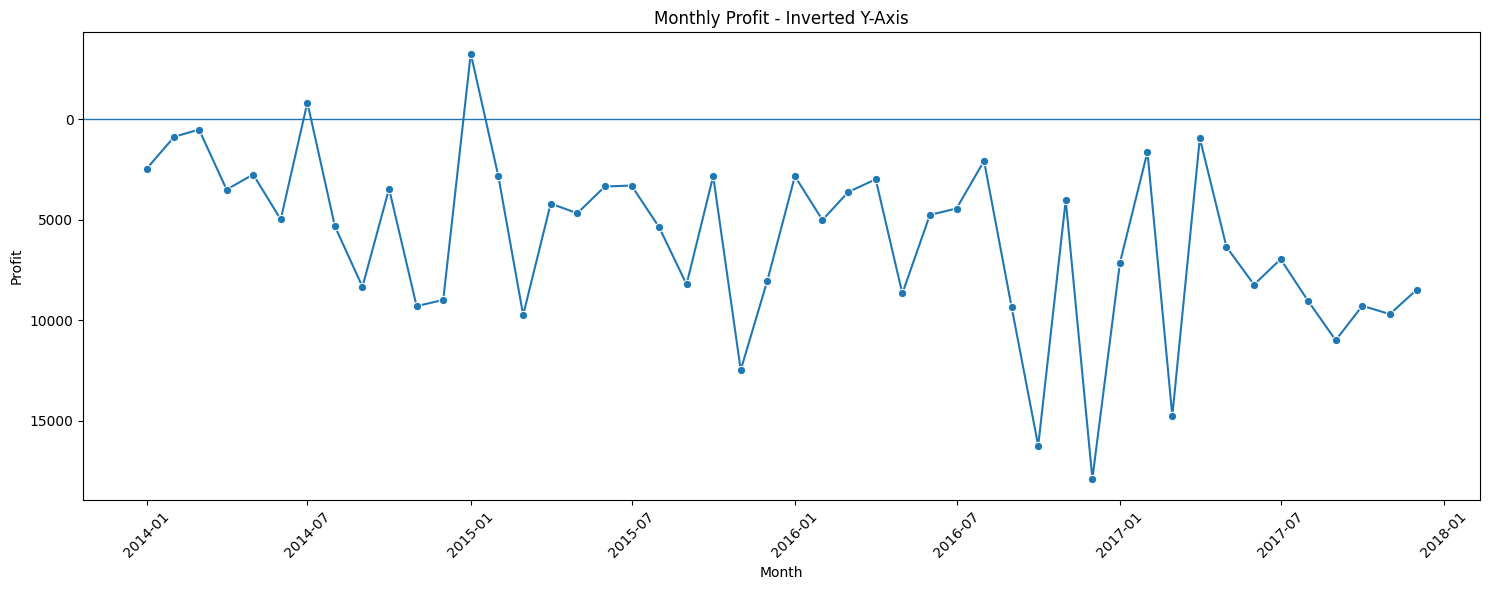

In [88]:

plt.figure(figsize=(15, 6))

sns.lineplot(
    data=monthly_profit,
    x="Order Date",
    y="Profit",
    marker="o"
)

plt.gca().invert_yaxis()

plt.axhline(0, linewidth=1)

plt.title("Monthly Profit - Inverted Y-Axis")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

task 6

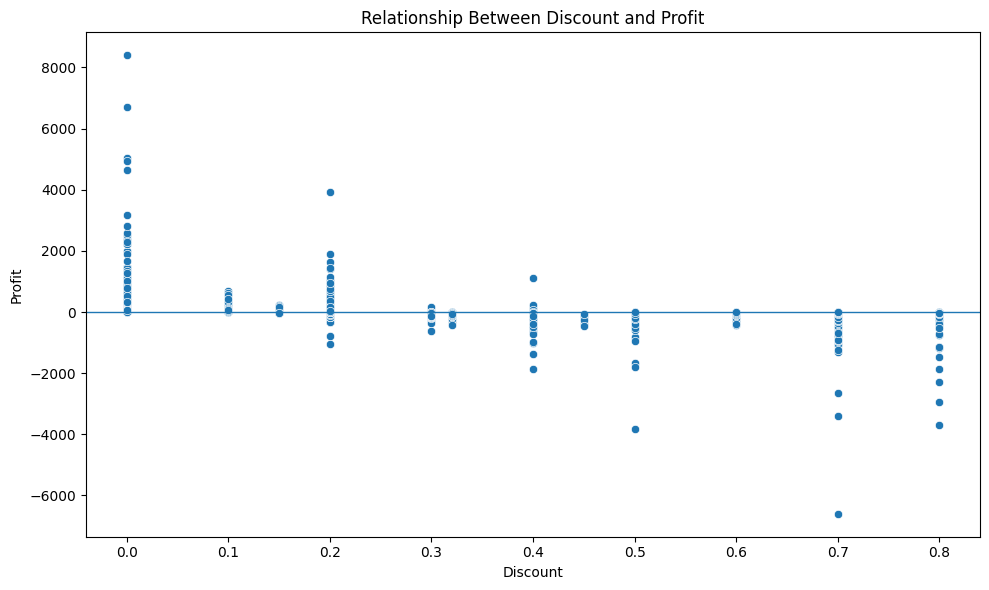

In [89]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit"
)

plt.axhline(0, linewidth=1)

plt.title("Relationship Between Discount and Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

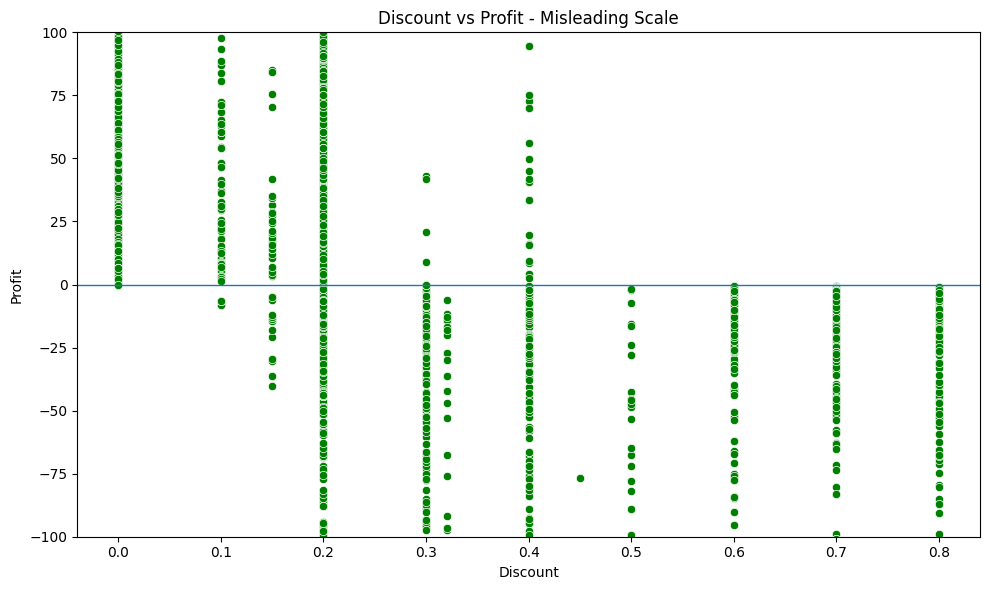

In [91]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    color="green"
)

plt.ylim(-100, 100)

plt.axhline(0, linewidth=1)

plt.title("Discount vs Profit - Misleading Scale")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

the scatterplot is good for showing relationsipps between two categories. its a good choice to use a consistent solid color for this instead of radients or smth. The visualization does not rely on red versus green alone to communicate meaning. The zero-profit reference line and axis labels provide additional ways to interpret the chart.